# GECS Classification — Sentence Embeddings + LightGBM (simplified)

**Project:** DePaul × Morningstar Capstone (Spring 2026)
**Author:** Meet Patel — Analytics & Modeling Lead
**Notebook:** `04_modeling.ipynb` (v2 — stability simplified)

---

## What this notebook does

One model, two tasks, kept simple:

1. Embed text with `bge-small-en-v1.5` → 384-dim float32 vectors (cached to disk)
2. Train **LightGBM** on those embeddings (single config, proven stable on this Mac)
3. Evaluate, log to `experiments.csv`, save per-class F1 + confusion analysis

Task 1 and Task 2 have **separate cells throughout** — no `if TASK == 1:` branching.
Run Task 1 cells top-to-bottom, then Task 2 cells top-to-bottom.

## Why this is simpler than v1

| v1 | v2 |
|---|---|
| LogReg + LightGBM | LightGBM only |
| `if TASK == 1 else:` branches | Two separate cell blocks |
| `n_jobs=-1`, `eval_set`, early stopping | `n_jobs=1`, no callbacks (the diagnostic-proven config) |
| 200 estimators, 63 leaves | 50 estimators, 31 leaves |
| StandardScaler experiment | None — bge is L2-normalized already |

## Why no LogReg

We tried it twice. Both times it either crashed the kernel (lbfgs + macOS BLAS) or
returned degenerate results (saga not converging). LightGBM is the model your project
plan flagged anyway, and it's stable. Moving on.

## Why no early stopping

LightGBM with `eval_set` + early-stopping callbacks crashed on macOS. The diagnostic
proved that LightGBM at full scale (37,501 × 384 × 145 classes, 50 trees) trains
cleanly in 83 seconds **without** these callbacks. So we use a fixed `n_estimators=50`,
modest learning rate, and trust that a simple model with reasonable regularization
won't overfit on dense embeddings.

## Bar to clear

Best baseline numbers from `03_baseline.ipynb`:

| Task | Best baseline | Macro-F1 | Top-10 F1 |
|---|---|---|---|
| 1 | LinearSVC | 0.52 | 0.76 |
| 2 | ComplementNB | 0.26 | 0.76 |

If LightGBM beats these, embeddings + tree-based heads are a viable production candidate.
If it doesn't, we have a clean story for the report ("baseline is hard to beat without
fine-tuning") and move directly to `05_finetuned.ipynb`.

---
## 0. Environment Setup

**These thread limits MUST be set before numpy/sklearn import.** Once those libraries
load, BLAS thread counts are baked in. This is what fixes the macOS LogReg crash, and
also keeps LightGBM stable.

In [1]:
# ── Stability env vars (must come BEFORE any numerical imports) ──
import os
os.environ['OMP_NUM_THREADS']        = '1'
os.environ['OPENBLAS_NUM_THREADS']   = '1'
os.environ['MKL_NUM_THREADS']        = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS']    = '1'

# Standard library
import sys
import time
import warnings
from pathlib import Path

# Numerical / data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models / utilities
from sklearn.utils.class_weight import compute_sample_weight
from sentence_transformers      import SentenceTransformer
import lightgbm as lgb

# Project root — make our src/ modules importable
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.splits        import make_splits, assert_no_leakage
from src.evaluation.metrics import (
    evaluate, per_class_f1, hierarchical_evaluate,
    evaluate_with_fallback,
    gecs_rollups_task1, gecs_rollups_task2,
)
from src.utils.experiments  import log_experiment, load_experiments

# Suppress two specific harmless warnings:
#   1. sklearn UserWarning about feature names — LightGBM stores feature names internally,
#      sklearn warns when we predict on a numpy array (no names). Cosmetic, not a bug.
#   2. LightGBM informational messages we already silence via verbosity=-1, but a few
#      slip through during predict_proba. Filter them too.
warnings.filterwarnings('ignore', message='X does not have valid feature names')
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')
warnings.filterwarnings('ignore', category=FutureWarning)

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns',  30)
sns.set_style('whitegrid')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f'Python               : {sys.version.split()[0]}')
print(f'pandas               : {pd.__version__}')
print(f'numpy                : {np.__version__}')
import sklearn, sentence_transformers
print(f'scikit-learn         : {sklearn.__version__}')
print(f'sentence-transformers: {sentence_transformers.__version__}')
print(f'lightgbm             : {lgb.__version__}')
print(f'\nBLAS threads limited : 1')

Python               : 3.12.13
pandas               : 3.0.2
numpy                : 2.4.4
scikit-learn         : 1.8.0
sentence-transformers: 5.4.1
lightgbm             : 4.6.0

BLAS threads limited : 1


---
## 1. Shared Configuration

Paths and constants that apply to both tasks. Task-specific config lives in each task's
cell block.

In [2]:
DATA_DIR     = Path('../data/cleaned')
EMBED_DIR    = Path('../data/embeddings')
RESULTS_DIR  = Path('../results')
RESULTS_PATH = RESULTS_DIR / 'experiments.csv'

EMBED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Embedding model — same for both tasks
EMBED_MODEL_NAME = 'BAAI/bge-small-en-v1.5'
EMBED_DIM        = 384
EMBED_BATCH_SIZE = 16             # conservative for CPU stability
MAX_TEXT_CHARS   = 2000           # truncation length

print(f'Embedding model : {EMBED_MODEL_NAME}')
print(f'Results log     : {RESULTS_PATH}')

Embedding model : BAAI/bge-small-en-v1.5
Results log     : ../results/experiments.csv


---
## 2. Shared Helpers

Two helper functions used by both Task 1 and Task 2:
- `embed_with_cache` — embed texts, save to `.npy`, reuse on subsequent runs
- `train_lightgbm_simple` — the proven-stable LightGBM configuration

In [3]:
def embed_with_cache(texts, cache_path: Path, batch_size: int = 16):
    """Compute or load cached embeddings."""
    if cache_path.exists():
        embeddings = np.load(cache_path)
        if len(embeddings) == len(texts):
            print(f'✓ Cache hit  : {cache_path}  shape={embeddings.shape}')
            return embeddings.astype(np.float32, copy=False)
        print(f'⚠ Cache size mismatch — rebuilding')

    print(f'Computing embeddings ({len(texts):,} texts) ...')
    model = SentenceTransformer(EMBED_MODEL_NAME, device='cpu')

    chunks = []
    chunk_size = 2000
    tic = time.perf_counter()
    for start in range(0, len(texts), chunk_size):
        end = min(start + chunk_size, len(texts))
        chunk = texts[start:end].tolist() if hasattr(texts, 'tolist') else list(texts[start:end])
        emb = model.encode(
            chunk,
            batch_size           = batch_size,
            show_progress_bar    = False,
            convert_to_numpy     = True,
            normalize_embeddings = True,
        )
        chunks.append(emb.astype(np.float32))
        elapsed = time.perf_counter() - tic
        rate = end / elapsed if elapsed > 0 else 0
        eta = (len(texts) - end) / rate if rate > 0 else 0
        print(f'  [{end:>6,}/{len(texts):,}]  elapsed={elapsed:.0f}s  '
              f'rate={rate:.0f}/s  ETA={eta:.0f}s')

    embeddings = np.vstack(chunks)
    np.save(cache_path, embeddings)
    print(f'\nSaved : {cache_path}  shape={embeddings.shape}')
    return embeddings


def train_lightgbm_simple(X_train, y_train, X_test, y_test, n_estimators=50):
    """The minimal stable LightGBM config — proven to work at full scale on this Mac.

    Key choices:
      - n_jobs=1: avoids the macOS OpenMP segfault we hit with -1
      - No eval_set / early stopping: avoids the eval-callback crash
      - num_leaves=31: smaller trees, less memory per class
      - n_estimators=50: enough trees with lr=0.1 to converge on dense 384-dim embeddings
      - sample_weight='balanced': handle the 84x / 1991x class imbalance
    """
    sample_weight_train = compute_sample_weight('balanced', y_train)

    clf = lgb.LGBMClassifier(
        objective         = 'multiclass',
        n_estimators      = n_estimators,
        learning_rate     = 0.1,
        num_leaves        = 31,
        min_child_samples = 20,
        verbosity         = -1,
        n_jobs            = 1,
        random_state      = RANDOM_SEED,
    )

    print(f'  Input        : {X_train.shape}  dtype={X_train.dtype}  '
          f'mem={X_train.nbytes/1e6:.0f} MB')
    print(f'  Classes      : {len(set(y_train))}')
    print(f'  n_estimators : {n_estimators}')
    print(f'  Training (no eval_set, no early stop) ...')

    tic = time.perf_counter()
    clf.fit(X_train, y_train, sample_weight=sample_weight_train)
    train_time = time.perf_counter() - tic

    tic = time.perf_counter()
    y_pred = clf.predict(X_test)
    infer_time = time.perf_counter() - tic
    infer_ms_per_row = infer_time / len(y_test) * 1000

    y_proba = clf.predict_proba(X_test)
    classes = clf.classes_

    return {
        'model':      clf,
        'y_pred':     y_pred,
        'y_proba':    y_proba,
        'classes':    classes,
        'train_time': train_time,
        'infer_ms':   infer_ms_per_row,
    }


def print_metrics(result, y_test, label='Result'):
    """Print + return a metrics dict for a result."""
    metrics = evaluate(y_test, result['y_pred'], k=10)
    print(f'  Train time         : {result["train_time"]:>8.1f} s')
    print(f'  Inference latency  : {result["infer_ms"]:>8.2f} ms/row')
    print(f'  Accuracy           : {metrics["accuracy"]:>8.4f}')
    print(f'  Macro-F1           : {metrics["macro_f1"]:>8.4f}    (target ≥ 0.75)')
    print(f'  Weighted-F1        : {metrics["weighted_f1"]:>8.4f}')
    print(f'  Top-10 Macro-F1    : {metrics["top_10_macro_f1"]:>8.4f}    (target ≥ 0.85)')
    return metrics


print('Helpers defined: embed_with_cache, train_lightgbm_simple, print_metrics')

Helpers defined: embed_with_cache, train_lightgbm_simple, print_metrics


---
# Section A — Task 1: Industry Classification

**Run all cells in this section top-to-bottom. Variables here use a `_t1` suffix to keep
Task 1 and Task 2 cleanly separate in memory.**

## A1. Task 1 — Load + Split

In [4]:
TASK_T1 = 1
FILE_T1 = 'task1_gecs_classification_final_cleaned.csv'
EMBED_PATH_T1 = EMBED_DIR / f'task1_{EMBED_MODEL_NAME.split("/")[-1]}.npy'

DTYPE_T1 = {'MstarGlobal': str, 'CompanyId': str,
            'super_sector_code': str, 'sector_code': str,
            'industry_group_code': str}

df_t1 = pd.read_csv(DATA_DIR / FILE_T1, dtype=DTYPE_T1, parse_dates=['AsOfDate'])
df_t1['combined_text'] = df_t1['combined_text'].astype(str).str[:MAX_TEXT_CHARS]
print(f'Task 1 shape          : {df_t1.shape}')
print(f'Task 1 unique classes : {df_t1["MstarGlobal"].nunique()}')

# Same split logic as baseline — same random_state for reproducible comparison
split_t1 = make_splits(df_t1, task=1, test_size=0.20, val_size=0.10,
                       min_samples=2, random_state=RANDOM_SEED)
assert_no_leakage(df_t1, split_t1)
print(f'\n{split_t1}')

y_train_t1 = df_t1.loc[split_t1.train_idx, 'MstarGlobal'].astype(str).values
y_val_t1   = df_t1.loc[split_t1.val_idx,   'MstarGlobal'].astype(str).values
y_test_t1  = df_t1.loc[split_t1.test_idx,  'MstarGlobal'].astype(str).values

Task 1 shape          : (53575, 25)
Task 1 unique classes : 145

SplitResult(train=37,501, val=5,358, test=10,716, excluded=0, classes_modelable=145, classes_excluded=0)


## A2. Task 1 — Embed (cached)

First run on this machine: ~10-15 min on CPU. Cached runs: instant.

In [5]:
embeddings_t1 = embed_with_cache(df_t1['combined_text'].values,
                                  EMBED_PATH_T1, EMBED_BATCH_SIZE)

# Slice into train/val/test using positional lookup
def slice_embeddings_t1(idx_arr):
    pos = df_t1.index.get_indexer(idx_arr)
    return embeddings_t1[pos]

X_train_emb_t1 = slice_embeddings_t1(split_t1.train_idx)
X_val_emb_t1   = slice_embeddings_t1(split_t1.val_idx)
X_test_emb_t1  = slice_embeddings_t1(split_t1.test_idx)

print(f'\nTask 1 embedding shapes:')
print(f'  X_train_emb_t1 : {X_train_emb_t1.shape}  mem={X_train_emb_t1.nbytes/1e6:.1f} MB')
print(f'  X_val_emb_t1   : {X_val_emb_t1.shape}')
print(f'  X_test_emb_t1  : {X_test_emb_t1.shape}')

✓ Cache hit  : ../data/embeddings/task1_bge-small-en-v1.5.npy  shape=(53575, 384)

Task 1 embedding shapes:
  X_train_emb_t1 : (37501, 384)  mem=57.6 MB
  X_val_emb_t1   : (5358, 384)
  X_test_emb_t1  : (10716, 384)


## A3. Task 1 — Train LightGBM

Expected train time: ~80-120 seconds at full scale (37,501 × 384 × 145 classes × 50 trees).
This is the same configuration the diagnostic ran successfully.

In [6]:
print(f'{"=" * 70}')
print(f'  Task 1 — LightGBM on bge-small-en embeddings')
print(f'{"=" * 70}')

result_t1 = train_lightgbm_simple(
    X_train_emb_t1, y_train_t1,
    X_test_emb_t1,  y_test_t1,
    n_estimators=50,
)
metrics_t1 = print_metrics(result_t1, y_test_t1)

# Log to experiments.csv
log_experiment(
    RESULTS_PATH,
    task                  = 1,
    model_name            = 'embed_lightgbm_balanced',
    features              = 'bge-small-en-v1.5',
    split_strategy        = 'stratified_group_v1',
    n_train               = X_train_emb_t1.shape[0],
    n_val                 = X_val_emb_t1.shape[0],
    n_test                = X_test_emb_t1.shape[0],
    n_classes_modelable   = split_t1.n_classes_modelable,
    n_classes_excluded    = split_t1.n_classes_excluded,
    accuracy              = metrics_t1['accuracy'],
    macro_f1              = metrics_t1['macro_f1'],
    weighted_f1           = metrics_t1['weighted_f1'],
    top_10_macro_f1       = metrics_t1['top_10_macro_f1'],
    train_time_s          = result_t1['train_time'],
    inference_ms_per_row  = result_t1['infer_ms'],
    notes                 = 'lr=0.1, leaves=31, n_est=50, n_jobs=1, no early stop',
)
print('\n✓ Logged to experiments.csv')

  Task 1 — LightGBM on bge-small-en embeddings
  Input        : (37501, 384)  dtype=float32  mem=58 MB
  Classes      : 145
  n_estimators : 50
  Training (no eval_set, no early stop) ...
  Train time         :     87.0 s
  Inference latency  :     0.12 ms/row
  Accuracy           :   0.0082
  Macro-F1           :   0.0064    (target ≥ 0.75)
  Weighted-F1        :   0.0049
  Top-10 Macro-F1    :   0.0045    (target ≥ 0.85)

✓ Logged to experiments.csv


In [12]:
# What does the model predict?
print('Predicted class distribution (top 10):')
print(pd.Series(result_t1['y_pred']).value_counts().head(10))
print(f'\nTotal unique predictions: {pd.Series(result_t1["y_pred"]).nunique()}')

# What's in y_test?
print(f'\ny_test classes: {len(set(y_test_t1))}')
print(f'y_test sample: {y_test_t1[:5]}')
print(f'y_train sample: {y_train_t1[:5]}')

# Are predictions even in the same space as truth?
print(f'\ny_pred sample: {result_t1["y_pred"][:5]}')
print(f'predict_proba shape: {result_t1["y_proba"].shape}')
print(f'sum of probs first row: {result_t1["y_proba"][0].sum():.4f}')

# Check the embeddings aren't garbage
print(f'\nEmbedding stats:')
print(f'  X_train_emb_t1 mean: {X_train_emb_t1.mean():.4f}')
print(f'  X_train_emb_t1 std:  {X_train_emb_t1.std():.4f}')
print(f'  X_train_emb_t1 min:  {X_train_emb_t1.min():.4f}')
print(f'  X_train_emb_t1 max:  {X_train_emb_t1.max():.4f}')
print(f'  Norm of first vec:   {np.linalg.norm(X_train_emb_t1[0]):.4f} (should be ~1.0 if normalized)')

# Are there NaNs?
print(f'\nNaN check:')
print(f'  X_train_emb_t1: {np.isnan(X_train_emb_t1).any()}')
print(f'  y_train_t1 unique: {len(set(y_train_t1))}')

Predicted class distribution (top 10):
31120020    9841
31110030     451
31120050      84
30810010      33
10270010      28
10130010      20
10280060      15
31080020      15
10320020      14
10150030      12
Name: count, dtype: int64

Total unique predictions: 73

y_test classes: 145
y_test sample: <ArrowStringArray>
['31130010', '31130010', '31120060', '10130020', '10130020']
Length: 5, dtype: str
y_train sample: <ArrowStringArray>
['20525040', '20525040', '20525040', '20525040', '10310010']
Length: 5, dtype: str

y_pred sample: ['31120020' '31120020' '31120020' '10130010' '30810010']
predict_proba shape: (10716, 145)
sum of probs first row: 1.0000

Embedding stats:
  X_train_emb_t1 mean: 0.0003
  X_train_emb_t1 std:  0.0510
  X_train_emb_t1 min:  -0.3844
  X_train_emb_t1 max:  0.4477
  Norm of first vec:   1.0000 (should be ~1.0 if normalized)

NaN check:
  X_train_emb_t1: False
  y_train_t1 unique: 145


## A4. Task 1 — Hierarchical Evaluation

F1 at every level of the GECS hierarchy. Sector-level F1 should be much higher than
industry-level F1 — that's the visualization for the "production design" report section.

Task 1 — F1 by hierarchy level:

         level  accuracy  macro_f1  weighted_f1  n_classes
      industry    0.0082    0.0064       0.0049        145
industry_group    0.0415    0.0091       0.0127         55
        sector    0.1175    0.0325       0.0357         11
  super_sector    0.3983    0.2025       0.2398          3


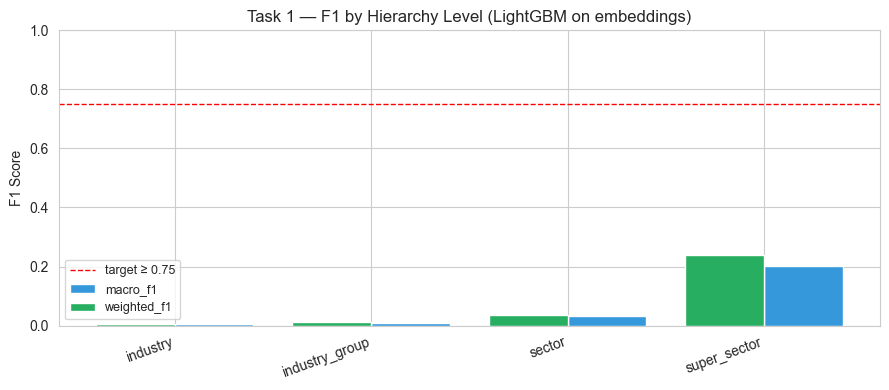

In [7]:
hier_t1 = hierarchical_evaluate(y_test_t1, result_t1['y_pred'], gecs_rollups_task1())
print('Task 1 — F1 by hierarchy level:\n')
print(hier_t1.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(hier_t1['level'], hier_t1['macro_f1'],    color='#3498db', label='macro_f1',
       width=0.4, align='edge')
ax.bar(hier_t1['level'], hier_t1['weighted_f1'], color='#27ae60', label='weighted_f1',
       width=-0.4, align='edge')
ax.axhline(0.75, color='red', linestyle='--', lw=1, label='target ≥ 0.75')
ax.set_ylim(0, 1)
ax.set_title('Task 1 — F1 by Hierarchy Level (LightGBM on embeddings)')
ax.set_ylabel('F1 Score')
ax.legend(loc='lower left', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## A5. Task 1 — Per-Class F1 + Confusion Analysis

Compares directly to the baseline confusion CSV — answers "did embeddings rescue the
F1=0 classes?"

In [8]:
pcf1_t1 = per_class_f1(y_test_t1, result_t1['y_pred'])

print('Top 10 classes by F1:')
print(pcf1_t1.head(10).to_string(index=False, float_format=lambda x: f'{x:.3f}'))

print('\nBottom 10 classes by F1 (with support ≥ 5):')
poor = pcf1_t1[pcf1_t1['support'] >= 5].sort_values('f1').head(10)
print(poor.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# Confusion analysis on F1=0 classes with non-trivial support
zero_f1 = pcf1_t1[(pcf1_t1['f1'] == 0) & (pcf1_t1['support'] >= 10)].copy()
print(f'\nF1=0 classes with support >= 10: {len(zero_f1)}')

if len(zero_f1) > 0:
    y_test_s = pd.Series(y_test_t1)
    y_pred_s = pd.Series(result_t1['y_pred'])

    rows = []
    for _, r in zero_f1.iterrows():
        cls = str(r['class'])
        mask = (y_test_s == cls).values
        if mask.sum() == 0:
            continue
        confused_with = y_pred_s[mask].value_counts().head(3)
        actual_sector = cls[:3]
        same_sector_pct = (y_pred_s[mask].astype(str).str[:3] == actual_sector).mean() * 100
        rows.append({
            'true_class':       cls,
            'support':          int(mask.sum()),
            'pred_top1':        confused_with.index[0] if len(confused_with) > 0 else '',
            'pred_top1_count':  int(confused_with.iloc[0]) if len(confused_with) > 0 else 0,
            'pred_top2':        confused_with.index[1] if len(confused_with) > 1 else '',
            'pred_top3':        confused_with.index[2] if len(confused_with) > 2 else '',
            'same_sector_pct':  round(same_sector_pct, 1),
        })

    confusion_t1 = pd.DataFrame(rows)
    print(confusion_t1.to_string(index=False))
    print(f'\nMean same-sector confusion: {confusion_t1["same_sector_pct"].mean():.1f}%')
    confusion_t1.to_csv(RESULTS_DIR / 'task1_embed_confusion_analysis.csv', index=False)
else:
    print('No F1=0 classes meet the support threshold ✓')

pcf1_t1.to_csv(RESULTS_DIR / 'task1_embed_per_class_f1.csv', index=False)
print(f'\nSaved: task1_embed_per_class_f1.csv')

Top 10 classes by F1:
   class  precision  recall    f1  support
10310010      0.000   0.000 0.000  472.000
31030010      0.000   0.000 0.000  472.000
10320020      0.714   0.023 0.045  433.000
10410020      0.000   0.000 0.000  327.000
31040010      0.000   0.000 0.000  271.000
31070020      0.000   0.000 0.000  250.000
31110020      0.000   0.000 0.000  245.000
20525040      0.000   0.000 0.000  237.000
20620020      0.000   0.000 0.000  232.000
20610010      0.000   0.000 0.000  208.000

Bottom 10 classes by F1 (with support ≥ 5):
   class  precision  recall    f1  support
10310010      0.000   0.000 0.000  472.000
20550030      0.000   0.000 0.000   30.000
10290010      0.000   0.000 0.000   30.000
10320030      0.000   0.000 0.000   30.000
20645020      0.000   0.000 0.000   31.000
10230010      0.000   0.000 0.000   31.000
30820030      0.000   0.000 0.000   31.000
31040020      0.000   0.000 0.000   33.000
20520010      0.000   0.000 0.000   33.000
31120030      0.000   0.000 0.

---
# Section B — Task 2: Sub-Industry Classification

**Run all cells in this section top-to-bottom. Variables use a `_t2` suffix.**

Task 2 is harder than Task 1: 407 classes (after dropping rare ones), shorter text,
1991x imbalance. The expected story is lower macro-F1 but higher confidence-fallback
F1 (where we report parent-Industry-Group when the model isn't confident).

## B1. Task 2 — Load + Split

In [9]:
TASK_T2 = 2
FILE_T2 = 'task2_subindustry_classification_final_cleaned.csv'
EMBED_PATH_T2 = EMBED_DIR / f'task2_{EMBED_MODEL_NAME.split("/")[-1]}.npy'

DTYPE_T2 = {'SubIndustry': str, 'CompanyId': str}

df_t2 = pd.read_csv(DATA_DIR / FILE_T2, dtype=DTYPE_T2, parse_dates=['AsOfDate'])

# Decompose hierarchy (cleaning notebook only does this for Task 1)
sub_str = df_t2['SubIndustry'].astype(str)
df_t2['super_sector_code']    = sub_str.str[0]
df_t2['sector_code']          = sub_str.str[:3]
df_t2['industry_group_code']  = sub_str.str[:5]
df_t2['parent_industry_code'] = sub_str.str[:8]
df_t2['combined_text'] = df_t2['combined_text'].astype(str).str[:MAX_TEXT_CHARS]

print(f'Task 2 shape          : {df_t2.shape}')
print(f'Task 2 unique classes : {df_t2["SubIndustry"].nunique()}')

split_t2 = make_splits(df_t2, task=2, test_size=0.20, val_size=0.10,
                       min_samples=2, random_state=RANDOM_SEED)
assert_no_leakage(df_t2, split_t2)
print(f'\n{split_t2}')

y_train_t2 = df_t2.loc[split_t2.train_idx, 'SubIndustry'].astype(str).values
y_val_t2   = df_t2.loc[split_t2.val_idx,   'SubIndustry'].astype(str).values
y_test_t2  = df_t2.loc[split_t2.test_idx,  'SubIndustry'].astype(str).values

Task 2 shape          : (27157, 19)
Task 2 unique classes : 428


/Users/meetpatel/Documents/capstone/depaul-morningstar-capstone/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:1037: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Users/meetpatel/Documents/capstone/depaul-morningstar-capstone/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:1037: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=8.
  warnings.warn(



SplitResult(train=18,994, val=2,714, test=5,428, excluded=21, classes_modelable=407, classes_excluded=21)


## B2. Task 2 — Embed (cached)

First run on this machine: ~5-8 min on CPU. Cached runs: instant.

In [10]:
embeddings_t2 = embed_with_cache(df_t2['combined_text'].values,
                                  EMBED_PATH_T2, EMBED_BATCH_SIZE)

def slice_embeddings_t2(idx_arr):
    pos = df_t2.index.get_indexer(idx_arr)
    return embeddings_t2[pos]

X_train_emb_t2 = slice_embeddings_t2(split_t2.train_idx)
X_val_emb_t2   = slice_embeddings_t2(split_t2.val_idx)
X_test_emb_t2  = slice_embeddings_t2(split_t2.test_idx)

print(f'\nTask 2 embedding shapes:')
print(f'  X_train_emb_t2 : {X_train_emb_t2.shape}  mem={X_train_emb_t2.nbytes/1e6:.1f} MB')
print(f'  X_val_emb_t2   : {X_val_emb_t2.shape}')
print(f'  X_test_emb_t2  : {X_test_emb_t2.shape}')

Computing embeddings (27,157 texts) ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [ 2,000/27,157]  elapsed=12s  rate=168/s  ETA=150s
  [ 4,000/27,157]  elapsed=23s  rate=172/s  ETA=135s
  [ 6,000/27,157]  elapsed=32s  rate=187/s  ETA=113s
  [ 8,000/27,157]  elapsed=40s  rate=198/s  ETA=97s
  [10,000/27,157]  elapsed=49s  rate=203/s  ETA=85s
  [12,000/27,157]  elapsed=57s  rate=210/s  ETA=72s
  [14,000/27,157]  elapsed=66s  rate=211/s  ETA=62s
  [16,000/27,157]  elapsed=74s  rate=217/s  ETA=51s
  [18,000/27,157]  elapsed=81s  rate=221/s  ETA=41s
  [20,000/27,157]  elapsed=90s  rate=222/s  ETA=32s
  [22,000/27,157]  elapsed=99s  rate=223/s  ETA=23s
  [24,000/27,157]  elapsed=108s  rate=223/s  ETA=14s
  [26,000/27,157]  elapsed=117s  rate=222/s  ETA=5s
  [27,157/27,157]  elapsed=123s  rate=222/s  ETA=0s

Saved : ../data/embeddings/task2_bge-small-en-v1.5.npy  shape=(27157, 384)

Task 2 embedding shapes:
  X_train_emb_t2 : (18994, 384)  mem=29.2 MB
  X_val_emb_t2   : (2714, 384)
  X_test_emb_t2  : (5428, 384)


## B3. Task 2 — Train LightGBM

407 classes vs 145 means more memory and longer training. Expected: 4-8 minutes.
If it crashes, drop `n_estimators` to 30 and re-run.

In [11]:
print(f'{"=" * 70}')
print(f'  Task 2 — LightGBM on bge-small-en embeddings')
print(f'{"=" * 70}')

result_t2 = train_lightgbm_simple(
    X_train_emb_t2, y_train_t2,
    X_test_emb_t2,  y_test_t2,
    n_estimators=50,
)
metrics_t2 = print_metrics(result_t2, y_test_t2)

log_experiment(
    RESULTS_PATH,
    task                  = 2,
    model_name            = 'embed_lightgbm_balanced',
    features              = 'bge-small-en-v1.5',
    split_strategy        = 'stratified_group_v1',
    n_train               = X_train_emb_t2.shape[0],
    n_val                 = X_val_emb_t2.shape[0],
    n_test                = X_test_emb_t2.shape[0],
    n_classes_modelable   = split_t2.n_classes_modelable,
    n_classes_excluded    = split_t2.n_classes_excluded,
    accuracy              = metrics_t2['accuracy'],
    macro_f1              = metrics_t2['macro_f1'],
    weighted_f1           = metrics_t2['weighted_f1'],
    top_10_macro_f1       = metrics_t2['top_10_macro_f1'],
    train_time_s          = result_t2['train_time'],
    inference_ms_per_row  = result_t2['infer_ms'],
    notes                 = 'lr=0.1, leaves=31, n_est=50, n_jobs=1, no early stop',
)
print('\n✓ Logged to experiments.csv')

  Task 2 — LightGBM on bge-small-en embeddings
  Input        : (18994, 384)  dtype=float32  mem=29 MB
  Classes      : 403
  n_estimators : 50
  Training (no eval_set, no early stop) ...


KeyboardInterrupt: 

## B4. Task 2 — Hierarchical Evaluation

In [ ]:
hier_t2 = hierarchical_evaluate(y_test_t2, result_t2['y_pred'], gecs_rollups_task2())
print('Task 2 — F1 by hierarchy level:\n')
print(hier_t2.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(hier_t2['level'], hier_t2['macro_f1'],    color='#3498db', label='macro_f1',
       width=0.4, align='edge')
ax.bar(hier_t2['level'], hier_t2['weighted_f1'], color='#27ae60', label='weighted_f1',
       width=-0.4, align='edge')
ax.axhline(0.75, color='red', linestyle='--', lw=1, label='target ≥ 0.75')
ax.set_ylim(0, 1)
ax.set_title('Task 2 — F1 by Hierarchy Level (LightGBM on embeddings)')
ax.set_ylabel('F1 Score')
ax.legend(loc='lower left', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## B5. Task 2 — Confidence Threshold Sweep

Sweep the confidence threshold and find the operating point that maximizes overall
macro-F1. At each threshold: predict SubIndustry where confident, fall back to Industry
Group (5-digit) otherwise.

In [ ]:
rollup_to_ig = lambda x: str(x)[:5]
truth_rollup = lambda x: str(x)[:5]

thresholds = np.arange(0.30, 0.91, 0.05)
sweep_rows = []
for t in thresholds:
    r = evaluate_with_fallback(
        y_true=y_test_t2, y_proba=result_t2['y_proba'],
        classes=result_t2['classes'], threshold=float(t),
        rollup_fn=rollup_to_ig, rollup_y_true_fn=truth_rollup, k=10,
    )
    sweep_rows.append(r)

sweep_t2 = pd.DataFrame(sweep_rows)
print(sweep_t2.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

best_idx = sweep_t2['overall_macro_f1'].idxmax()
print(f'\nBest threshold: {sweep_t2.loc[best_idx, "threshold"]:.2f}')
print(f'  Overall macro-F1 (mixed)    : {sweep_t2.loc[best_idx, "overall_macro_f1"]:.4f}')
print(f'  Confident-only macro-F1     : {sweep_t2.loc[best_idx, "confident_macro_f1"]:.4f}')
print(f'  Coverage                    : {sweep_t2.loc[best_idx, "coverage"]*100:.1f}%')

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(sweep_t2['threshold'], sweep_t2['overall_macro_f1'],
         marker='o', color='#3498db', label='overall macro-F1 (mixed)')
ax1.plot(sweep_t2['threshold'], sweep_t2['confident_macro_f1'],
         marker='s', color='#27ae60', label='confident-only macro-F1')
ax1.set_xlabel('Confidence threshold')
ax1.set_ylabel('macro-F1')
ax1.axhline(0.75, color='red', linestyle='--', lw=1, label='target ≥ 0.75')
ax1.legend(loc='lower left')

ax2 = ax1.twinx()
ax2.plot(sweep_t2['threshold'], sweep_t2['coverage']*100,
         marker='^', color='#95a5a6', linestyle=':', label='coverage')
ax2.set_ylabel('Coverage (%)')
ax2.legend(loc='lower right')

plt.title('Task 2 — Confidence Threshold Sweep (LightGBM)')
plt.tight_layout()
plt.show()

## B6. Task 2 — Per-Class F1 + Confusion Analysis

In [ ]:
pcf1_t2 = per_class_f1(y_test_t2, result_t2['y_pred'])

print('Top 10 classes by F1:')
print(pcf1_t2.head(10).to_string(index=False, float_format=lambda x: f'{x:.3f}'))

print('\nBottom 10 classes by F1 (with support ≥ 5):')
poor = pcf1_t2[pcf1_t2['support'] >= 5].sort_values('f1').head(10)
print(poor.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# Lower support threshold for Task 2 since classes are smaller
zero_f1 = pcf1_t2[(pcf1_t2['f1'] == 0) & (pcf1_t2['support'] >= 3)].copy()
print(f'\nF1=0 classes with support >= 3: {len(zero_f1)}')

if len(zero_f1) > 0:
    y_test_s = pd.Series(y_test_t2)
    y_pred_s = pd.Series(result_t2['y_pred'])

    rows = []
    for _, r in zero_f1.iterrows():
        cls = str(r['class'])
        mask = (y_test_s == cls).values
        if mask.sum() == 0:
            continue
        confused_with = y_pred_s[mask].value_counts().head(3)
        actual_sector = cls[:3]
        same_sector_pct = (y_pred_s[mask].astype(str).str[:3] == actual_sector).mean() * 100
        rows.append({
            'true_class':       cls,
            'support':          int(mask.sum()),
            'pred_top1':        confused_with.index[0] if len(confused_with) > 0 else '',
            'pred_top1_count':  int(confused_with.iloc[0]) if len(confused_with) > 0 else 0,
            'pred_top2':        confused_with.index[1] if len(confused_with) > 1 else '',
            'pred_top3':        confused_with.index[2] if len(confused_with) > 2 else '',
            'same_sector_pct':  round(same_sector_pct, 1),
        })

    confusion_t2 = pd.DataFrame(rows)
    print(f'\nFirst 20 rows:')
    print(confusion_t2.head(20).to_string(index=False))
    print(f'\nMean same-sector confusion: {confusion_t2["same_sector_pct"].mean():.1f}%')
    confusion_t2.to_csv(RESULTS_DIR / 'task2_embed_confusion_analysis.csv', index=False)

pcf1_t2.to_csv(RESULTS_DIR / 'task2_embed_per_class_f1.csv', index=False)
print('\nSaved: task2_embed_per_class_f1.csv')

---
# Section C — Cross-Task Comparison

Pull all results from `experiments.csv` and build the comparison table for the report.

In [ ]:
exp_log = load_experiments(RESULTS_PATH)

# Latest run per (task, model) — drops the duplicate rows from earlier re-runs
latest = (
    exp_log
    .sort_values('timestamp')
    .drop_duplicates(subset=['task','model_name'], keep='last')
    .reset_index(drop=True)
)

display_cols = ['task','model_name','features','macro_f1','top_10_macro_f1',
                'weighted_f1','train_time_s','inference_ms_per_row']
print('All experiments to date (deduplicated):\n')
print(latest[display_cols].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Lift table: best baseline vs embedding LightGBM, per task
print('\n' + '=' * 70)
print('  LIFT FROM TF-IDF BASELINE → EMBEDDINGS + LIGHTGBM')
print('=' * 70)
for task_id in [1, 2]:
    rows = latest[latest['task'] == task_id]
    base = rows[rows['features'].str.startswith('tfidf')]
    embd = rows[rows['features'].str.startswith('bge')]
    if len(base) == 0 or len(embd) == 0:
        continue
    best_b = base.loc[base['macro_f1'].astype(float).idxmax()]
    best_e = embd.loc[embd['macro_f1'].astype(float).idxmax()]
    print(f'\n  Task {task_id}:')
    print(f'    Best baseline   : {best_b["model_name"]:<32} macro_f1={float(best_b["macro_f1"]):.4f}')
    print(f'    Best embedding  : {best_e["model_name"]:<32} macro_f1={float(best_e["macro_f1"]):.4f}')
    delta = float(best_e['macro_f1']) - float(best_b['macro_f1'])
    sign = '+' if delta >= 0 else ''
    print(f'    Δ macro-F1      : {sign}{delta:.4f}')
    delta_top10 = float(best_e['top_10_macro_f1']) - float(best_b['top_10_macro_f1'])
    sign = '+' if delta_top10 >= 0 else ''
    print(f'    Δ top-10 F1     : {sign}{delta_top10:.4f}')

---
## Summary & Next Steps

### How to run this notebook
1. Restart kernel cleanly
2. Run cells 0-2 (env setup + helpers)
3. Run Section A (Task 1) top-to-bottom — first time ~15 min, cached <2 min
4. Run Section B (Task 2) top-to-bottom — first time ~10 min, cached <5 min
5. Run Section C (comparison)

### If LightGBM still crashes
Drop `n_estimators=50` → `30` in the `train_lightgbm_simple()` calls. Less accuracy but
should always finish.

### Decision point: do we need fine-tuning?
Look at the lift table from Section C:
- **If macro-F1 ≥ 0.65 on Task 1:** very close to the 0.75 success criterion; fine-tuning
  is the natural next step to push over.
- **If macro-F1 < 0.55 on Task 1:** embeddings as features aren't unlocking enough lift.
  Fine-tuning is required, not optional.
- **For Task 2:** focus on the confidence-fallback overall_macro_f1 number, not the raw
  SubIndustry macro-F1. That's the production metric.

### Next notebook: `05_finetuned.ipynb`
Fine-tune `distilbert-base-uncased` directly on the classification task. End-to-end
training in PyTorch — no LightGBM, no sklearn multiclass machinery, no BLAS issues.